# Ribasim Delwaq basisvoorbeeld
De stappen zijn grotendeels overgenomen van een ander [Ribasim Delwaq Coupling voorbeeld](https://ribasim.org/guide/delwaq.html). Deze workflow is een voorbeeld om:

1. Een Ribasim schematisatie in te laden en weer te geven
2. Toewijzen van concentraties en toevoegen van tracers in Ribasim model
3. Ribasim berekening uitvoeren
4. Genereren van een Delwaq schematisatie op basis van het Ribasim model
4. Delwaq berekeningen uitvoeren
5. Fracties van tracers per basins visualiseren

Om Delwaq invoerbestanden te genereren is een doorgerekend Ribasim model (meestal met `results` map) nodig. Ideaal heeft de Ribasim schematisatie ook enkele stoffen gedefinieerd en initiële concentraties.  

### Importeren van de benodigde libraries
De meeste packages spreken voor zich, deze workflow bevat naast standaard packages ook extra functionaliteit vanuit `ribasim_tools`. Alle packages zouden al binnen de huidige .pixi omgeving geïnstalleerd moeten zijn.

In [1]:
import shutil

import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display
from ribasim import Model
from ribasim.delwaq import add_tracer, generate, parse, plot_fraction

from ribasim_tools import download_testmodels, run_delwaq, run_ribasim, settings

### Downloaden van het Basic ribasim model vanuit de Ribasim GitHub repository
We nemen hier een voorbeeld model, als je een ander Ribasim model wilt inladen: verander het `toml_path` om een ander Ribasim model in te lezen. Ook kan je het `.env`-bestand aanpassen waarin dezelfde verwijzing staat naar de padnaam van het Ribasim model.

In [2]:
download_testmodels(overwrite=True)
toml_path = settings.data_dir.joinpath("generated_testmodels", "basic", "ribasim.toml")
assert toml_path.exists()

Test models downloaded.


### Inlezen en tonen van het basic Ribasim model
Het Ribasim test model heeft al de stof `Cl` en een `Tracer` voorgedefinieerd in de input tabellen. We gaan hier enkele toevoegen voordat we ze gebruiken voor de Ribasim en Delwaq input bestanden.

,node_id,substance,concentration
fid,,,
0,1,Cl,0.0
1,3,Cl,0.0
2,6,Cl,0.0
3,9,Cl,0.0


,node_id,time,substance,drainage,precipitation,surface_runoff
fid,,,,,,
0,1,2020-01-01,Cl,0.0,0.0,0.0
1,1,2020-01-02,Cl,1.0,1.0,1.0
2,1,2020-01-01,Tracer,1.0,1.0,1.0
3,3,2020-01-01,Cl,0.0,0.0,0.0
4,3,2020-01-02,Cl,1.0,1.0,1.0
5,3,2020-01-01,Tracer,1.0,1.0,1.0
6,6,2020-01-01,Cl,0.0,0.0,0.0
7,6,2020-01-02,Cl,1.0,1.0,1.0
8,6,2020-01-01,Tracer,1.0,1.0,1.0


,node_id,time,substance,concentration
fid,,,,
0,15,2020-01-01,Cl,0.0
1,15,2020-01-01,Tracer,1.0
2,16,2020-01-01,Cl,0.0
3,16,2020-01-01,Tracer,1.0


,node_id,time,substance,concentration
fid,,,,
0,11,2020-01-01,Cl,34.0
1,17,2020-01-01,Cl,34.0


,node_id,area,level,storage
fid,,,,
0,1,0.01,0.0,NaN
1,1,1000.00,1.0,NaN
2,3,0.01,0.0,NaN
3,3,1000.00,1.0,NaN
4,6,0.01,0.0,NaN
5,6,1000.00,1.0,NaN
6,9,0.01,0.0,NaN
7,9,1000.00,1.0,NaN


<Axes: >

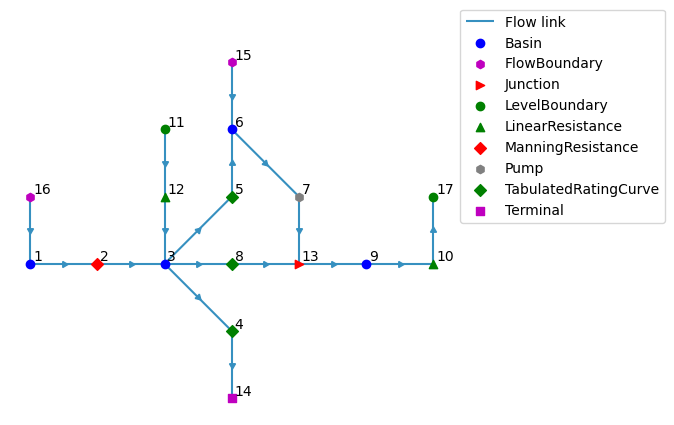

In [3]:
model = Model.read(toml_path)
display(model.basin.concentration_state)  # basin initial state
display(model.basin.concentration)  # basin boundaries
display(model.flow_boundary.concentration)  # flow boundaries
display(model.level_boundary.concentration)  # level boundaries
display(model.basin.profile)
model.plot()  # for later comparison

### Toevoegen van twee fictieve tracers Foo and Bar aan Node # 11 en Node # 15
Hier voegen we nog 2 tracers toe, aan knopen 11 en 15, en geven ze een label.
Merk op dat de concentraties zijn veranderd ten opzichte van de initiële waarden; aan de `FlowBoundary` is een extra rij `Bar` verschenen met een concentratie van 1. Bij de `LevelBoundary` is een extra rij `Foo` verschenen met een concentratie van 1.

In [4]:
add_tracer(model, 11, "Foo")
add_tracer(model, 15, "Bar")
display(model.flow_boundary.concentration)  # flow boundaries
display(model.level_boundary.concentration)  # level boundaries

,node_id,time,substance,concentration
fid,,,,
0,15,2020-01-01,Cl,0.0
1,15,2020-01-01,Tracer,1.0
2,16,2020-01-01,Cl,0.0
3,16,2020-01-01,Tracer,1.0
4,15,2020-01-01,Bar,1.0


,node_id,time,substance,concentration
fid,,,,
0,11,2020-01-01,Cl,34.0
1,17,2020-01-01,Cl,34.0
2,11,2020-01-01,Foo,1.0


### Eventuele resultaten uit een eerdere run verwijderen en het model opslaan op een nieuwe locatie
Het model wordt hier met ribasim.exe uitgevoerd. Mocht het crashen op het niet kunnen vinden van Ribasim dan kan je het pad naar Ribasim aanpassen in het `.env` bestand.

In [5]:
toml_path = settings.data_dir.joinpath("basic_delwaq") / model.filepath.name
shutil.rmtree(toml_path.parent, ignore_errors=True)
model.write(toml_path)
specs = run_ribasim(toml_path, settings.ribasim_exe)
assert specs.exit_code == 0

┌ Info: Starting a Ribasim simulation.
│   toml_path = "c:/GitHub/ribasim_delwaq_aam/data/basic_delwaq/basic_delwaq/ribasim.toml"
│   cli.ribasim_version = "2025.5.0"
│   starttime = 2020-01-01T00:00:00
│   endtime = 2021-01-01T00:00:00
└   threads = 1
┌ Warning: The following experimental features are enabled: concentration
└ @ Ribasim D:\buildAgent\work\ecd2b8f9b25b1609\ribasim\core\src\logging.jl:49
Simulating  78%|████████████████████████████████        |  ETA: 0:00:04         
[ Info: Computation time: 7 seconds, 644 milliseconds
[ Info: The model finished successfully.


### Genereren van het delwaq netwerk op basis van het Ribasim model
Met het pad naar een volledig doorgerekend Ribasim model kunnen we een Delwaq schematisatie opzetten. `generate` heeft een pad naar een (Ribasim) .toml-bestand nodig, of een `Model` object, en een pad naar een output map. De default waarde slaat de Delwaq input bestanden in een aparte `delwaq` map naast het .toml-bestand.

In [6]:
output_path = model.filepath.parent.joinpath("delwaq")
graph, substances = generate(toml_path, output_path)
list(output_path.iterdir())
list(substances)

c:\GitHub\ribasim_delwaq_aam\.pixi\envs\default\Lib\site-packages\ribasim\delwaq\generate.py:410: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  volumes["riba_node_id"] = volumes["node_id"]


['Foo',
 'Tracer',
 'Continuity',
 'Drainage',
 'Initial',
 'Bar',
 'Cl',
 'UserDemand',
 'LevelBoundary',
 'Terminal',
 'Precipitation',
 'FlowBoundary']

## Delwaq en ribasim schematisaties plotten

Hieronder worden de node ID's van de verschillende schematisatie getoond. Merk op dat elke basin in Ribasim wordt opgesplitst in 3 aparte bakjes. Door middel van de verschillende bakjes kan Delwaq de schematisatie opbouwen en er eigen node ID's van maken. De delwaq node ID's worden weer omgezet naar Ribasim ID's bij het inladen.

Text(0.5, 0.98, 'Delwaq network')

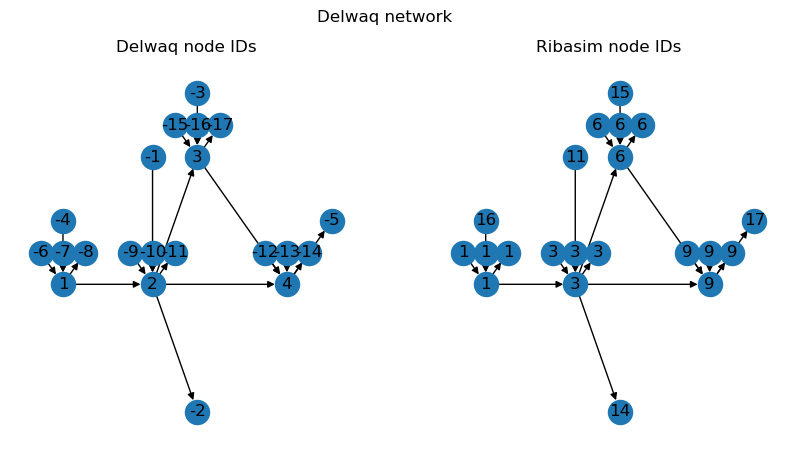

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
nx.draw(
    graph,
    pos={k: v["pos"] for k, v in graph.nodes(data=True)},
    with_labels=True,
    labels={k: k for k, v in graph.nodes(data=True)},
    ax=ax[0],
)
ax[0].set_title("Delwaq node IDs")
nx.draw(
    graph,
    pos={k: v["pos"] for k, v in graph.nodes(data=True)},
    with_labels=True,
    labels={k: v["id"] for k, v in graph.nodes(data=True)},
    ax=ax[1],
)
ax[1].set_title("Ribasim node IDs")
fig.suptitle("Delwaq network")

### Runnen van Delwaq met de DHydro DIMR
Onderstaande code runt de Delwaq input bestanden. We gebruiken hiervoor de D-Hydro DeltaShell dimr in plaats van de delwaq executable omdat deze betrouwbaarder is.

In [8]:
dimr_config = toml_path.parent.joinpath("delwaq", "dimr_config.xml")

specs = run_delwaq(dimr_config=dimr_config, run_dimr_bat=settings.run_dimr_bat)
assert specs.exit_code == 0

Configfile:C:/GitHub/ribasim_delwaq_aam/data/basic_delwaq/basic_delwaq/delwaq/dimr_config.xml
'wmic' is not recognized as an internal or external command,
operable program or batch file.
OMP_NUM_THREADS is -2
Working directory: C:\GitHub\ribasim_delwaq_aam\data\basic_delwaq\basic_delwaq\delwaq
D3D_HOME         : C:\Program Files\Deltares\D-HYDRO Suite 2025.01 1D2D\plugins\DeltaShell.Dimr\kernels\x64\bin\..
executing: "C:\Program Files\Deltares\D-HYDRO Suite 2025.01 1D2D\plugins\DeltaShell.Dimr\kernels\x64\bin\..\bin\dimr.exe"  C:/GitHub/ribasim_delwaq_aam/data/basic_delwaq/basic_delwaq/delwaq/dimr_config.xml
Dimr [2025-10-14 15:21:38.554] #0 >> Deltares, DIMR_EXE Version 2.00.16121e1c11da6767019cb454759df52aec1670fe, Oct 30 2024, 09:22:50
Dimr [2025-10-14 15:21:38.846] #0 >> Deltares, DIMR_LIB Version 1.02.16121e1c11da6767019cb454759df52aec1670fe, Oct 30 2024, 09:22:39
Dimr [2025-10-14 15:21:39.798] #0 >> 
Dimr [2025-10-14 15:21:39.798] #0 >> Version Information of Components
Dimr [202

### Inlezen van de Delwaq resultaten in het Ribasim model en plotten van de concentraties van de twee tracers in Basin #9
Hieronder een voorbeeld om de fracties te plotten van een van de basins (node #9).

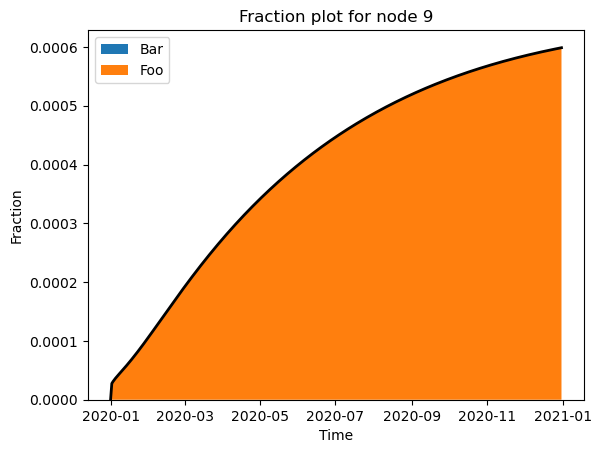

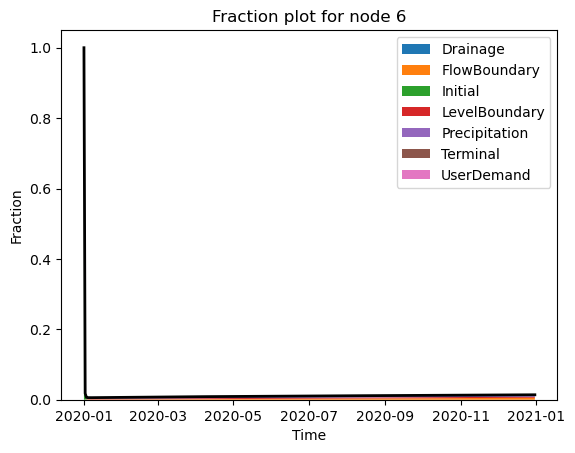

In [10]:
nmodel = parse(toml_path, graph, substances, output_folder=output_path)

plot_fraction(nmodel, 9, ["Foo", "Bar"])
plot_fraction(nmodel, 6)